# Ross parameter scan

Machines, spares and repairers

## Цель

Провести серию экспериментов для разного числа машин, резервных машин и
ремонтников.

## Подготовка

In [1]:
using DrWatson
@quickactivate "project"

using CSV
using Plots

include(srcdir("DESModels.jl"))

Main.DESModels

## Сканирование параметров

In [2]:
scan = DESModels.scan_ross_parameters(;
    machines_values = [6, 8, 10, 12],
    spares_values = [1, 2, 3, 5],
    repairers_values = [1, 2],
    runs = 150,
    seed = 700,
)

CSV.write(datadir("ross_scan.csv"), scan)
first(scan, 10)

## Влияние резерва


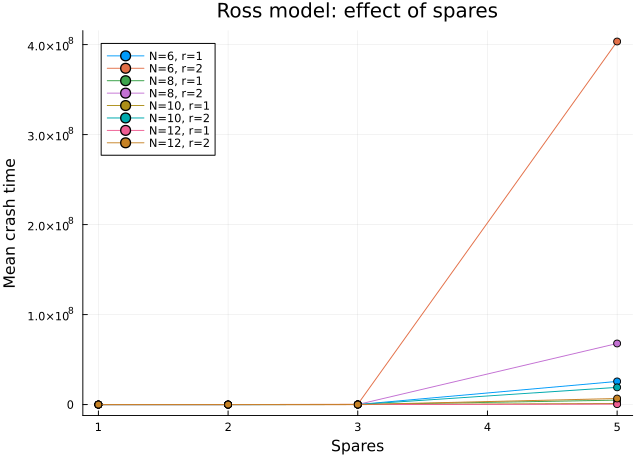

In [3]:
plt_spares = plot(
    xlabel = "Spares",
    ylabel = "Mean crash time",
    title = "Ross model: effect of spares",
)

for machines in sort(unique(scan.machines)), repairers in sort(unique(scan.repairers))
    subset = scan[(scan.machines .== machines) .& (scan.repairers .== repairers), :]
    sort!(subset, :spares)
    plot!(
        plt_spares,
        subset.spares,
        subset.mean_crash_time,
        marker = :circle,
        label = "N=$(machines), r=$(repairers)",
    )
end

savefig(plt_spares, plotsdir("ross_scan_spares.png"))
plt_spares

## Влияние числа ремонтников


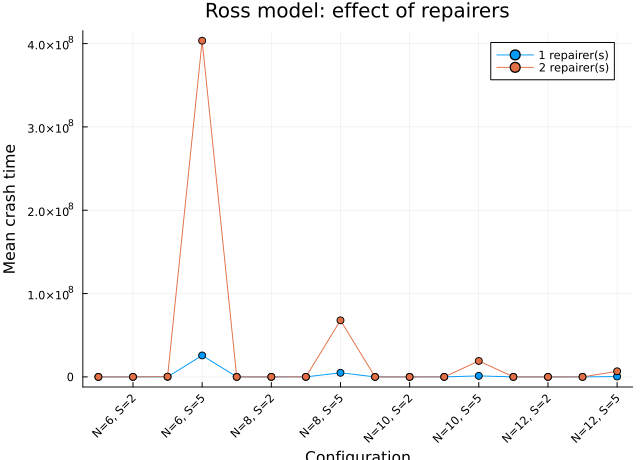

In [4]:
plt_repairers = plot(
    xlabel = "Configuration",
    ylabel = "Mean crash time",
    title = "Ross model: effect of repairers",
    xrotation = 45,
)

configs = sort(unique([(row.machines, row.spares) for row in eachrow(scan)]))
labels = ["N=$(c[1]), S=$(c[2])" for c in configs]

for repairers in sort(unique(scan.repairers))
    values = Float64[]
    for (machines, spares) in configs
        row = scan[(scan.machines .== machines) .& (scan.spares .== spares) .& (scan.repairers .== repairers), :]
        push!(values, row.mean_crash_time[1])
    end
    plot!(plt_repairers, labels, values, marker = :circle, label = "$(repairers) repairer(s)")
end

savefig(plt_repairers, plotsdir("ross_scan_repairers.png"))
plt_repairers

## Вывод

Рост числа резервных машин и ремонтников увеличивает среднее время до
падения системы. Сканирование параметров позволяет оценить вклад каждого
фактора.